# Prédiction du délai de retour à l'emploi — notebook principal

Ce notebook présente la démarche complète du projet : cadrage métier, préparation des données, modélisation multiclasse, analyse des risques de biais et trajectoire d'industrialisation.

Il est conçu comme un support de travail lisible pour un contexte portfolio et exploitable pour la soutenance.

## Lecture rapide
1. Cadrage métier et critères de succès
2. Données, qualité et préparation
3. Modélisation, évaluation et arbitrages
4. Industrialisation (API, monitoring, CI/CD)
5. Plan de suivi en production

## Livrables associés
- Notebook principal : notebooks/multimodal-classification.ipynb
- Support de soutenance : reports/soutenance/presentation-plan.md
- Journal de décisions : docs/runbooks/decision-log.md

## 0. Imports et configuration

Cette section centralise les imports, les constantes de reproductibilité et les chemins projet.
Le but est d'avoir un point d'entrée unique pour exécuter le notebook de manière stable.

In [72]:
# Imports standards
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Affichage
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")

# Chemins du projet (robuste quel que soit le dossier de lancement)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_RAW_DIR = DATA_DIR / "raw"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

## 0.5 Traçabilité de la session

Cette section enregistre les éléments nécessaires à la reproductibilité :

- version de Python et bibliothèques clés ;
- commit Git ;
- source, version et empreinte du dataset ;
- date/heure d'exécution.

Ces informations facilitent l'audit des résultats et le suivi des évolutions du projet.

In [73]:
import hashlib
import subprocess
import sys
from datetime import datetime
from importlib.metadata import version, PackageNotFoundError

# Localisation robuste du dataset (priorité à data/raw, fallback data/)
dataset_candidates = sorted(DATA_RAW_DIR.glob("*.csv"))
if not dataset_candidates:
    dataset_candidates = sorted(DATA_DIR.glob("*.csv"))

if not dataset_candidates:
    raise FileNotFoundError("Aucun fichier CSV trouvé dans data/raw ou data.")

DATASET_PATH = dataset_candidates[0]
DATASET_NAME = DATASET_PATH.name
try:
    DATASET_SOURCE = DATASET_PATH.relative_to(PROJECT_ROOT).as_posix()
except ValueError:
    # Fallback défensif : ne jamais exposer de chemin absolu
    DATASET_SOURCE = DATASET_NAME

DATASET_VERSION = datetime.fromtimestamp(DATASET_PATH.stat().st_mtime).strftime("%Y-%m-%d %H:%M")

# Empreinte du dataset pour la traçabilité
with open(DATASET_PATH, "rb") as f:
    dataset_sha256 = hashlib.sha256(f.read()).hexdigest()

# Métadonnées de session
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

packages_to_track = ["numpy", "pandas", "scikit-learn", "xgboost", "lightgbm", "mlflow"]
tracked_versions = {}
for pkg in packages_to_track:
    try:
        tracked_versions[pkg] = version(pkg)
    except PackageNotFoundError:
        tracked_versions[pkg] = "non installé"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME}")
print(f"Source       : {DATASET_SOURCE}")
print(f"Version data : {DATASET_VERSION}")
print(f"SHA256       : {dataset_sha256}")
print("\nVersions bibliothèques clés :")
for pkg, ver in tracked_versions.items():
    print(f"- {pkg:12s}: {ver}")

Date session : 2026-07-24T16:08
Python       : 3.12.10
Git commit   : 996e635
Dataset      : dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv
Source       : data/raw/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv
Version data : 2026-07-16 09:20
SHA256       : 2b9cb8c813b5f97540f0130b5e1cae2bad7ce5cbc1f57ffce51f54b498a7b34e

Versions bibliothèques clés :
- numpy       : 2.5.1
- pandas      : 2.3.3
- scikit-learn: 1.9.0
- xgboost     : 3.3.0
- lightgbm    : 4.6.0
- mlflow      : 3.14.0


---
## 1. Cadrage métier et problème

Cette section formalise le besoin métier, les critères de succès et les contraintes éthiques/réglementaires avant la phase de modélisation.

### 1.1 Contexte client

Le client est une agence nationale de l'emploi qui souhaite améliorer l'orientation des demandeurs d'emploi dès le premier entretien.
L'enjeu opérationnel est de classer chaque situation dans un niveau de risque de retour à l'emploi : rapide (< 6 mois), moyen (6-12 mois), ou risque de longue durée (> 12 mois).
L'objectif n'est pas de remplacer le conseiller, mais de fournir une aide à la décision plus homogène, traçable et réactive.
Cette aide doit rester compatible avec les contraintes du service public : explicabilité minimale, confidentialité, robustesse et non-discrimination.

### 1.2 Énoncé du problème IA

Tâche IA retenue : **classification supervisée multiclasse (3 classes)**.

Formulation : prédire `classe_retour_emploi` à partir de :
- variables tabulaires (âge, diplôme, ancienneté, allocation, géographie, etc.),
- variable textuelle `synthese_entretien` (notes conseiller),
- avec comparaison de scénarios imposés (multimodal, sans variable sensible, texte seul, tabulaire seul).

### 1.3 Bénéficiaires et impacts

Bénéficiaires directs :
- conseillers emploi en entretien d'orientation,
- managers opérationnels qui pilotent la répartition des accompagnements.

Bénéficiaires indirects :
- usagers, dont l'accès à un accompagnement renforcé dépend de la qualité de l'orientation initiale,
- administration publique (qualité de service, efficacité des politiques d'emploi).

Impact critique métier :
- une erreur **réelle classe 2 prédite classe 0** est la plus coûteuse humainement et financièrement (perte de chance d'accompagnement renforcé).

### 1.4 Critères de succès

La cible initiale est définie avant EDA ; la cible révisée sera confirmée après EDA (section 3).

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Réduire les erreurs critiques (2 -> 0) | <= 5 % sur jeu de test | À confirmer | Dépend de l'équilibre des classes et de la qualité texte |
| Modèle | F1-score macro | >= 0.70 | À confirmer | Métrique adaptée au multiclasse potentiellement déséquilibré |
| Modèle | Recall classe 2 | >= 0.80 | À confirmer | Priorité métier sur la détection des situations à risque longue durée |
| Opérationnel | Latence inférence API | < 300 ms en p95 | À confirmer | Doit rester compatible avec un entretien en face-à-face |
| Gouvernance | Traçabilité décisionnelle | 100 % des inférences journalisées | 100 % | Exigence de pilotage, audit et amélioration continue |

### 1.5 Risques éthiques et réglementaires anticipés

Risques majeurs identifiés :
- **Biais et discrimination** liés à l'usage direct ou indirect de variables sensibles (ex. `nationalite_hors_ue`).
- **Biais de texte** : les verbatims peuvent contenir des formulations hétérogènes selon les conseillers.
- **Risque métier** : sous-estimer des cas graves (classe 2 -> 0).

Cadre réglementaire à respecter :
- RGPD : minimisation des données, finalité explicite, sécurité, journalisation proportionnée.
- Principes de non-discrimination (service public / cadre juridique national).
- Exigence d'explicabilité suffisante pour justifier une recommandation d'orientation.

Mesures prévues dès la conception :
- comparaison explicite du scénario avec et sans variable sensible,
- suivi des erreurs critiques par classe et par profil,
- documentation des arbitrages dans le decision log et le journal de bord.

### 1.6 Synthèse cadrage

Le cas d'usage est un problème de classification multiclasse à fort enjeu social, où l'objectif principal n'est pas seulement la performance globale, mais la réduction des erreurs critiques sur les profils à risque.
La stratégie de modélisation sera évaluée selon un compromis : qualité prédictive (F1 macro + recall classe 2), robustesse opérationnelle (latence, traçabilité) et conformité éthique/réglementaire.
Les sections suivantes valideront ces hypothèses via l'EDA, la comparaison des scénarios et l'analyse des risques de biais.

---
## 2. Identification et acquisition des données

Cette section documente la source, le format, la volumétrie et la traçabilité du jeu de données avant tout traitement.
L'objectif est de valider l'adéquation entre la donnée disponible et le besoin métier.

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| Jeu fourni dans le sujet d'examen CISIA (fichier local) | Table tabulaire enrichie d'un champ texte | 2 500 lignes, 10 colonnes | CSV | Lecture locale (repo, dossier `data/raw`) | 16/07/2026 |

**Localisation projet** : `data/raw/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv`

**Traçabilité** : version source, SHA256 et contexte d'exécution sont suivis en section 0.5.

In [74]:
# 2.2 Chargement
from pathlib import Path

import pandas as pd

# On privilégie la variable DATASET_PATH définie en section 0.
# Fallback : on cherche le premier CSV dans data/raw.
if "DATASET_PATH" in globals() and Path(DATASET_PATH).exists():
    dataset_path = Path(DATASET_PATH)
else:
    raw_dir = Path("data/raw")
    candidates = sorted(raw_dir.glob("*.csv"))
    if not candidates:
        raise FileNotFoundError("Aucun CSV trouvé dans data/raw")
    dataset_path = candidates[0]

df = pd.read_csv(dataset_path)

# Affichage sans chemin absolu
project_root = Path(PROJECT_ROOT) if "PROJECT_ROOT" in globals() else Path.cwd().parent
dataset_rel = dataset_path.resolve().relative_to(project_root.resolve())

print(f"Dataset chargé : {dataset_rel.as_posix()}")
print(f"Dimensions    : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("\nColonnes :")
print(df.columns.tolist())

display(df.head(3))

Dataset chargé : data/raw/dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv
Dimensions    : 2500 lignes x 10 colonnes

Colonnes :
['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi']


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0


### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | Identifiant technique du dossier usager | catégorielle (ID) | `ID_0000` ... `ID_2499` | ❌ | ❌ |
| `age` | Âge de l'usager | numérique | valeurs positives (années), avec manquants observés | ❌ | ✅ (proxy possible) |
| `niveau_diplome` | Niveau de diplôme déclaré | catégorielle ordonnée | ex. `Sans diplôme`, `Bac`, `Bac+2`, ... | ❌ | ❌ |
| `anciennete_poste_ans` | Ancienneté sur le dernier poste (années) | numérique | valeurs réelles >= 0 | ❌ | ❌ |
| `code_rome_vise` | Code métier visé (ROME) | catégorielle | codes alphanumériques (ex. `D1503`) | ❌ | ❌ |
| `code_insee_commune` | Code INSEE de la commune | catégorielle | codes commune (5 caractères) | ❌ | ✅ (proxy territorial) |
| `est_allocataire` | Statut allocataire (oui/non) | binaire | `0` / `1` + manquants | ❌ | ✅ (proxy socio-éco) |
| `nationalite_hors_ue` | Indicateur de nationalité hors UE | binaire | `0` / `1` | ❌ | ✅ (variable sensible) |
| `synthese_entretien` | Texte libre de synthèse conseiller | texte | verbatim court à moyen | ❌ | ✅ (peut contenir des signaux sensibles) |
| `classe_retour_emploi` | Classe cible de délai de retour à l'emploi | catégorielle (3 classes) | `0`, `1`, `2` | ✅ | ❌ |

### 2.4 Synthèse acquisition

Le dataset est cohérent avec le besoin métier posé en section 1 : il combine des variables socio-professionnelles tabulaires et un texte d'entretien, ce qui permet une approche multimodale.

Points d'attention détectés dès l'acquisition :
- présence de variables sensibles ou de proxys potentiels (`nationalite_hors_ue`, `age`, `code_insee_commune`, `est_allocataire`),
- présence de valeurs manquantes visibles dès l'aperçu sur certaines colonnes (`age`, `est_allocataire`),
- présence d'un champ texte non structuré (`synthese_entretien`) nécessitant une préparation dédiée.

Ces constats seront quantifiés et documentés dans l'EDA (section 3) avant le design final des pipelines de préparation (section 4).

---
## 3. Exploration et analyse des données (EDA)

L'EDA vise à qualifier la donnée avant modélisation : qualité, distributions, déséquilibres et signaux de biais.
Chaque analyse est reliée à une décision de préparation ou de modélisation.

### 3.1 Premier coup d'œil

Vérification de la structure générale du dataset : dimensions, aperçu, types et statistiques descriptives.

In [75]:
# Pré-requis section 3
assert "df" in globals(), "Le DataFrame df doit être chargé en section 2.2"

display(df.head(5))
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")

print("\nTypes de variables :")
display(df.dtypes.to_frame("dtype"))

print("\nDescription statistique (numériques) :")
display(df.describe(include=["number"]).T)

print("\nDescription statistique (catégorielles) :")
display(df.describe(include=["object", "category"]).T)

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


Dimensions : 2500 lignes x 10 colonnes

Types de variables :


,dtype
usager_id,object
age,float64
niveau_diplome,object
anciennete_poste_ans,float64
code_rome_vise,object
code_insee_commune,object
est_allocataire,float64
nationalite_hors_ue,int64
synthese_entretien,object
classe_retour_emploi,int64



Description statistique (numériques) :


,count,mean,std,min,25%,50%,75%,max
age,2378.0,40.566442,13.225242,18.0,29.0,41.0,52.0,63.0
anciennete_poste_ans,2500.0,2.971600,2.979548,0.0,0.8,2.0,4.1,22.6
est_allocataire,2456.0,0.595684,0.490859,0.0,0.0,1.0,1.0,1.0
nationalite_hors_ue,2500.0,0.118000,0.322673,0.0,0.0,0.0,0.0,1.0
classe_retour_emploi,2500.0,0.806400,0.719671,0.0,0.0,1.0,1.0,2.0



Description statistique (catégorielles) :


,count,unique,top,freq
usager_id,2500,2500,ID_0000,1
niveau_diplome,2416,4,Bac,966
code_rome_vise,2500,50,H1206,71
code_insee_commune,2500,2407,46283,3
synthese_entretien,2419,9,Compétences à réactualiser sur les outils numé...,338


### 3.2 Qualité des données

Contrôle des valeurs manquantes, des doublons et détection simple d'aberrations sur variables numériques (règle IQR).

Valeurs manquantes par variable :


,nb_manquants,pct_manquants
age,122,4.88
niveau_diplome,84,3.36
synthese_entretien,81,3.24
est_allocataire,44,1.76
usager_id,0,0.00
anciennete_poste_ans,0,0.00
code_insee_commune,0,0.00
code_rome_vise,0,0.00
nationalite_hors_ue,0,0.00
classe_retour_emploi,0,0.00


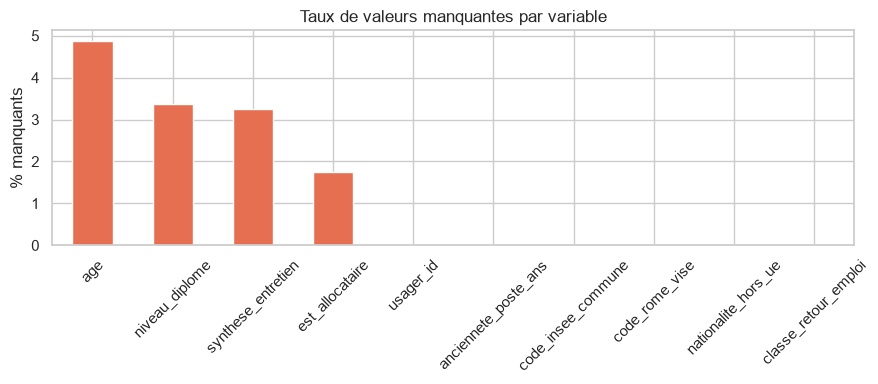

Doublons stricts (lignes complètes) : 0

Détection simple d'aberrations (règle IQR) :


,variable,nb_outliers_iqr,pct_outliers_iqr
3,nationalite_hors_ue,295,11.80
1,anciennete_poste_ans,126,5.04
0,age,0,0.00
2,est_allocataire,0,0.00
4,classe_retour_emploi,0,0.00


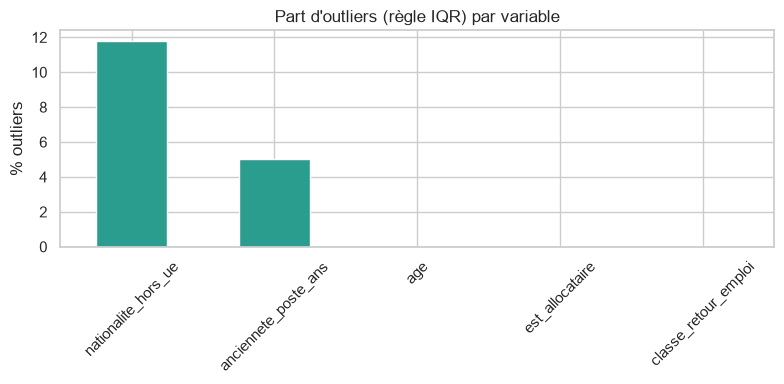

In [76]:
import matplotlib.pyplot as plt

n_rows = len(df)

missing = (
    df.isna().sum()
    .to_frame("nb_manquants")
    .assign(pct_manquants=lambda x: (x["nb_manquants"] / n_rows * 100).round(2))
    .sort_values("pct_manquants", ascending=False)
)
print("Valeurs manquantes par variable :")
display(missing)

# Graphique 1 : taux de manquants par variable
fig, ax = plt.subplots(figsize=(9, 4))
missing["pct_manquants"].plot(kind="bar", ax=ax, color="#e76f51")
ax.set_title("Taux de valeurs manquantes par variable")
ax.set_ylabel("% manquants")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

nb_duplicates = int(df.duplicated().sum())
print(f"Doublons stricts (lignes complètes) : {nb_duplicates}")

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
outliers = []
for col in num_cols:
    s = df[col].dropna()
    if s.empty:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < low) | (s > high)).sum())
    outliers.append({"variable": col, "nb_outliers_iqr": n_out, "pct_outliers_iqr": round(n_out / len(s) * 100, 2)})

outliers_df = pd.DataFrame(outliers).sort_values("pct_outliers_iqr", ascending=False)
print("\nDétection simple d'aberrations (règle IQR) :")
display(outliers_df)

# Graphique 2 : part d'observations hors bornes IQR
fig, ax = plt.subplots(figsize=(8, 4))
outliers_df.plot(kind="bar", x="variable", y="pct_outliers_iqr", ax=ax, legend=False, color="#2a9d8f")
ax.set_title("Part d'outliers (règle IQR) par variable")
ax.set_ylabel("% outliers")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Distributions des variables

Exploration des distributions numériques et des modalités catégorielles les plus fréquentes.

Variables numériques :


,count,mean,std,min,25%,50%,75%,max
age,2378.0,40.566442,13.225242,18.0,29.0,41.0,52.0,63.0
anciennete_poste_ans,2500.0,2.971600,2.979548,0.0,0.8,2.0,4.1,22.6
est_allocataire,2456.0,0.595684,0.490859,0.0,0.0,1.0,1.0,1.0
nationalite_hors_ue,2500.0,0.118000,0.322673,0.0,0.0,0.0,0.0,1.0
classe_retour_emploi,2500.0,0.806400,0.719671,0.0,0.0,1.0,1.0,2.0


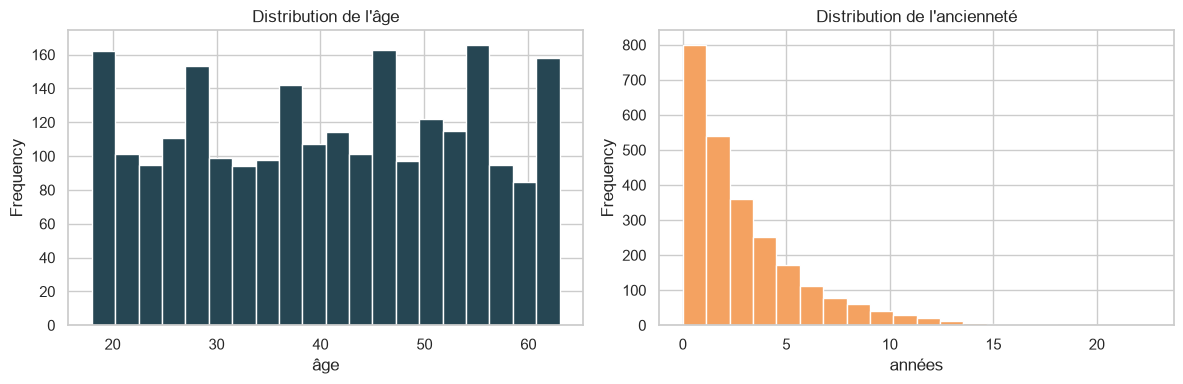


Synthèse des variables catégorielles (cardinalité + manquants) :


,variable,nb_modalites,pct_manquants
0,usager_id,2500,0.00
3,code_insee_commune,2407,0.00
2,code_rome_vise,50,0.00
4,synthese_entretien,9,3.24
1,niveau_diplome,4,3.36


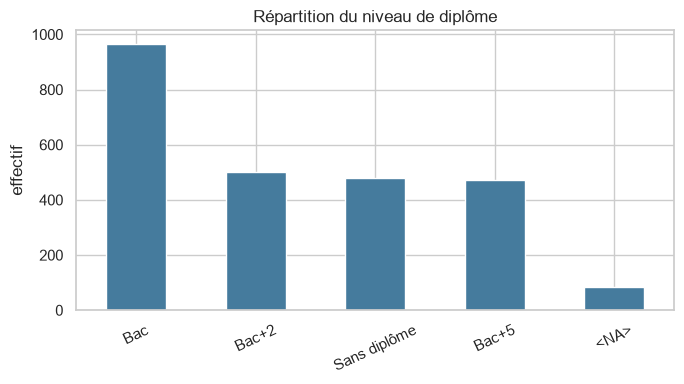

In [77]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numériques :")
display(df[num_cols].describe().T)

# Graphique 1 : distributions de variables numériques clés
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["age"].dropna().plot(kind="hist", bins=20, ax=axes[0], color="#264653")
axes[0].set_title("Distribution de l'âge")
axes[0].set_xlabel("âge")

df["anciennete_poste_ans"].dropna().plot(kind="hist", bins=20, ax=axes[1], color="#f4a261")
axes[1].set_title("Distribution de l'ancienneté")
axes[1].set_xlabel("années")
plt.tight_layout()
plt.show()

print("\nSynthèse des variables catégorielles (cardinalité + manquants) :")
cat_summary = pd.DataFrame({
    "variable": cat_cols,
    "nb_modalites": [df[c].nunique(dropna=True) for c in cat_cols],
    "pct_manquants": [round(df[c].isna().mean() * 100, 2) for c in cat_cols],
}).sort_values("nb_modalites", ascending=False)
display(cat_summary)

# Affichage compact par défaut
if "niveau_diplome" in df.columns:
    diplome_counts = df["niveau_diplome"].fillna("<NA>").value_counts()
    fig, ax = plt.subplots(figsize=(7, 4))
    diplome_counts.plot(kind="bar", ax=ax, color="#457b9d")
    ax.set_title("Répartition du niveau de diplôme")
    ax.set_ylabel("effectif")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()

# Optionnel : passer à True pour le détail des top modalités
SHOW_DETAILED_CATS = False
if SHOW_DETAILED_CATS:
    focus_cats = ["niveau_diplome", "code_rome_vise", "synthese_entretien"]
    print("\nTop modalités (aperçu ciblé) :")
    for col in focus_cats:
        if col not in df.columns:
            continue
        topk = df[col].fillna("<NA>").value_counts(dropna=False).head(5)
        topk_df = topk.rename_axis(col).to_frame("effectif")
        topk_df["part_pct"] = (topk_df["effectif"] / len(df) * 100).round(2)

        topk_plot = topk.copy()
        topk_plot.index = [str(v)[:70] + ("..." if len(str(v)) > 70 else "") for v in topk_plot.index]

        print(f"\n- {col}")
        display(topk_df)

        fig, ax = plt.subplots(figsize=(8, 3.5))
        topk_plot.sort_values().plot(kind="barh", ax=ax, color="#457b9d")
        ax.set_title(f"Top 5 modalités - {col}")
        ax.set_xlabel("effectif")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()

### 3.4 Variable cible : équilibre des classes

Mesure de la distribution de `classe_retour_emploi` pour évaluer un éventuel déséquilibre de classes.

Distribution de la variable cible :


,effectif,part_pct
classe_retour_emploi,,
0,936,37.44
1,1112,44.48
2,452,18.08


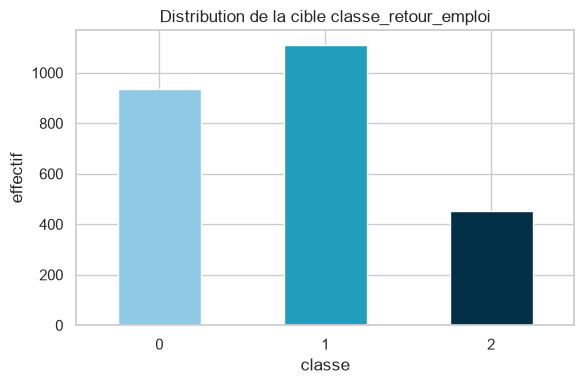

Classe majoritaire : 44.48% du dataset


In [78]:
import matplotlib.pyplot as plt

target_col = "classe_retour_emploi"
assert target_col in df.columns, f"Colonne cible absente : {target_col}"

target_dist = (
    df[target_col]
    .value_counts(dropna=False)
    .rename_axis(target_col)
    .to_frame("effectif")
    .sort_index()
)
target_dist["part_pct"] = (target_dist["effectif"] / target_dist["effectif"].sum() * 100).round(2)

print("Distribution de la variable cible :")
display(target_dist)

fig, ax = plt.subplots(figsize=(6, 4))
target_dist["effectif"].plot(kind="bar", ax=ax, color=["#8ecae6", "#219ebc", "#023047"])
ax.set_title("Distribution de la cible classe_retour_emploi")
ax.set_xlabel("classe")
ax.set_ylabel("effectif")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

majority_pct = float(target_dist["part_pct"].max())
print(f"Classe majoritaire : {majority_pct:.2f}% du dataset")

### 3.5 Relations entre variables et cible

Lecture des corrélations numériques et de croisements simples entre variables clés et cible.

Corrélations avec la cible (ordre décroissant en valeur absolue) :


,corr_avec_cible
age,0.260681
nationalite_hors_ue,0.220764
anciennete_poste_ans,0.085816
est_allocataire,-0.001211


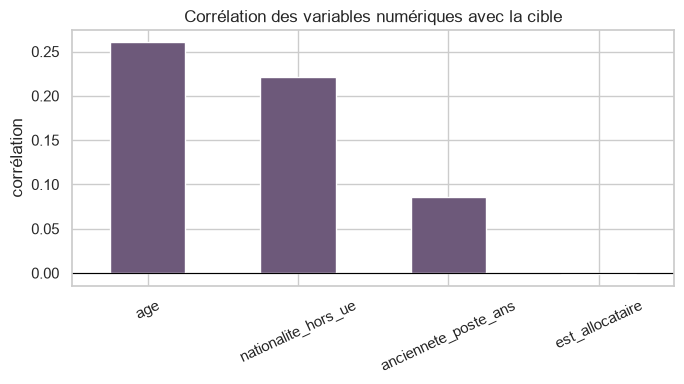


Répartition de la cible conditionnelle à est_allocataire :


classe_retour_emploi,0,1,2
est_allocataire,,,
0.0,0.379,0.435,0.186
1.0,0.371,0.452,0.177


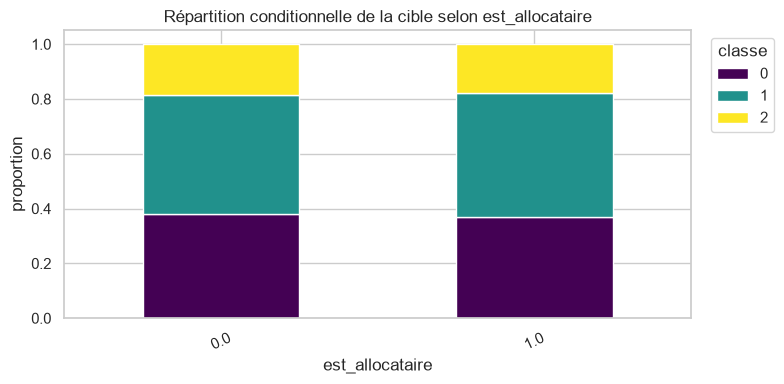


Répartition de la cible conditionnelle à nationalite_hors_ue :


classe_retour_emploi,0,1,2
nationalite_hors_ue,,,
0,0.406,0.440,0.154
1,0.139,0.481,0.380


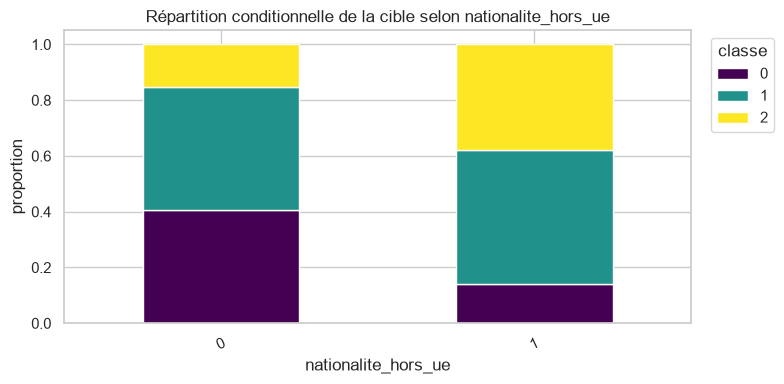


Répartition de la cible conditionnelle à niveau_diplome :


classe_retour_emploi,0,1,2
niveau_diplome,,,
Bac,0.377,0.481,0.142
Bac+2,0.377,0.495,0.128
Bac+5,0.635,0.293,0.072
Sans diplôme,0.119,0.467,0.414


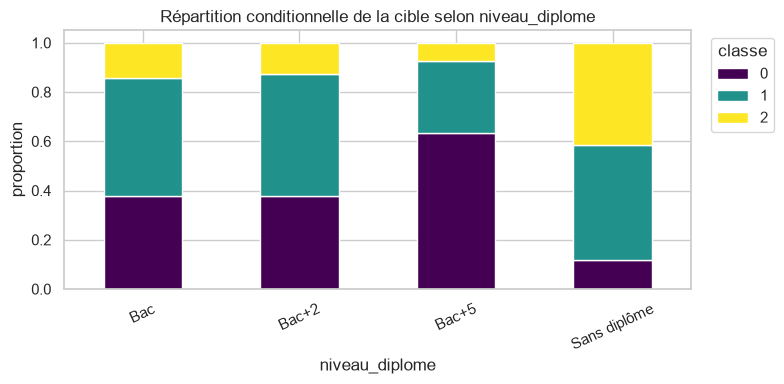

In [79]:
import matplotlib.pyplot as plt

target_col = "classe_retour_emploi"
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Corrélations numériques (hors auto-corrélation cible)
if target_col in num_cols:
    corr_target = (
        df[num_cols]
        .corr(numeric_only=True)[target_col]
        .drop(labels=[target_col])
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .to_frame("corr_avec_cible")
    )
    print("Corrélations avec la cible (ordre décroissant en valeur absolue) :")
    display(corr_target)

    fig, ax = plt.subplots(figsize=(7, 4))
    corr_target["corr_avec_cible"].plot(kind="bar", ax=ax, color="#6d597a")
    ax.set_title("Corrélation des variables numériques avec la cible")
    ax.set_ylabel("corrélation")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()

# Croisements simples avec variables clés
for col in ["est_allocataire", "nationalite_hors_ue", "niveau_diplome"]:
    if col in df.columns:
        ct = pd.crosstab(df[col], df[target_col], normalize="index").round(3)
        print(f"\nRépartition de la cible conditionnelle à {col} :")
        display(ct)

        fig, ax = plt.subplots(figsize=(8, 4))
        ct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
        ax.set_title(f"Répartition conditionnelle de la cible selon {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("proportion")
        ax.legend(title="classe", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.tick_params(axis="x", rotation=25)
        plt.tight_layout()
        plt.show()

### 3.6 Analyse des biais et variables sensibles

Variables sensibles ou proxys identifiés à surveiller :
- `nationalite_hors_ue` (sensible directe),
- `age`, `est_allocataire`, `code_insee_commune` (proxys potentiels socio-éco/territoriaux),
- `synthese_entretien` (texte libre pouvant embarquer des signaux sensibles).

Constats exploratoires issus des croisements :
- `nationalite_hors_ue = 1` présente une part de classe 2 plus élevée (38,0 %) que `nationalite_hors_ue = 0` (15,4 %).
- `niveau_diplome = Sans diplôme` présente une part de classe 2 élevée (41,4 %) vs `Bac+5` (7,2 %).
- `est_allocataire` montre un écart plus limité sur la classe 2 (18,6 % vs 17,7 %).

Lecture : ces écarts peuvent refléter des réalités de terrain, mais aussi des biais de collecte ou de formulation. Ils imposent une comparaison explicite des scénarios avec/sans variable sensible (décision DEC-006).

### 3.7 Synthèse EDA

Top enseignements :
1. Le dataset est exploitable (2 500 lignes, 10 variables) avec un mix tabulaire + texte pertinent pour le scénario multimodal.
2. Les manquants sont modérés mais non négligeables : `age` 4,88 %, `niveau_diplome` 3,36 %, `synthese_entretien` 3,24 %, `est_allocataire` 1,76 %.
3. Pas de doublons stricts détectés ; une attention particulière sera portée aux valeurs extrêmes d'`anciennete_poste_ans` en préprocessing.
4. La cible est modérément déséquilibrée : classe 1 = 44,48 %, classe 0 = 37,44 %, classe 2 = 18,08 %.
5. Des écarts marqués existent selon certaines variables sensibles/proxys (notamment `nationalite_hors_ue` et `niveau_diplome`).

Implications pour la modélisation (sections 4 à 6) :
- Mettre en place une imputation reproductible (numérique/catégorielle + texte manquant),
- Conserver des métriques adaptées au déséquilibre (F1 macro + recall classe 2),
- Suivre explicitement le risque d'erreurs critiques (2 -> 0),
- Comparer de façon argumentée les scénarios avec et sans variable sensible.

Révision des cibles section 1.4 :
- Les cibles sont maintenues à ce stade ; elles seront ajustées uniquement après premiers résultats de validation croisée sur les 4 scénarios.

---
## 4. Préparation des données

Cette section construit un pipeline de préprocessing reproductible, compatible avec les quatre scénarios de comparaison.
Le protocole suit une règle stricte anti-fuite : séparation train/test avant tout ajustement de transformation.

### 4.1 Train/Test Split (stratifié)

Objectif : figer un découpage d'évaluation propre, sans fuite de données, et préparer les listes de variables pour le pipeline de préprocessing.

In [80]:
from sklearn.model_selection import train_test_split

target_col = "classe_retour_emploi"
text_feature = "synthese_entretien"
id_cols = ["usager_id"]

assert target_col in df.columns, f"Cible absente: {target_col}"

# Séparation X/y
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# On exclut les identifiants techniques du modèle
excluded_from_model = [c for c in id_cols if c in X.columns]
X_model = X.drop(columns=excluded_from_model, errors="ignore")

# Listes de features pour la section 4.2
num_features = X_model.select_dtypes(include=["number"]).columns.tolist()
cat_features = X_model.select_dtypes(include=["object", "category"]).columns.tolist()
if text_feature in cat_features:
    cat_features.remove(text_feature)

assert text_feature in X_model.columns, f"Feature texte absente: {text_feature}"
assert len(num_features) + len(cat_features) + 1 == X_model.shape[1], "Incohérence de partition des features"

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
    shuffle=True,
 )

print(f"Taille totale   : {len(df)}")
print(f"Train/Test      : {X_train.shape} / {X_test.shape}")
print(f"Num features    : {len(num_features)} -> {num_features}")
print(f"Cat features    : {len(cat_features)} -> {cat_features}")
print(f"Text feature    : {text_feature}")
print(f"Colonnes exclues: {excluded_from_model}")

print("\nDistribution cible (global / train / test) :")
dist_global = y.value_counts(normalize=True).sort_index().rename("global")
dist_train = y_train.value_counts(normalize=True).sort_index().rename("train")
dist_test = y_test.value_counts(normalize=True).sort_index().rename("test")
display(pd.concat([dist_global, dist_train, dist_test], axis=1).round(4))

assert (len(X_train) + len(X_test)) == len(X_model), "Split incomplet"
assert set(y_train.unique()) == set(y_test.unique()) == set(y.unique()), "Perte de classe lors du split"

Taille totale   : 2500
Train/Test      : (2000, 8) / (500, 8)
Num features    : 4 -> ['age', 'anciennete_poste_ans', 'est_allocataire', 'nationalite_hors_ue']
Cat features    : 3 -> ['niveau_diplome', 'code_rome_vise', 'code_insee_commune']
Text feature    : synthese_entretien
Colonnes exclues: ['usager_id']

Distribution cible (global / train / test) :


,global,train,test
classe_retour_emploi,,,
0,0.3744,0.3745,0.374
1,0.4448,0.4445,0.446
2,0.1808,0.1810,0.180


### 4.2 Pipeline de préprocessing (numérique, catégoriel, texte)

Objectif : définir un préprocessing unique, reproductible et sans fuite, qui sera branché ensuite aux modèles en section 5.

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Pipeline numérique : imputation robuste + mise à l'échelle
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline catégoriel : imputation + one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Pipeline texte : sécuriser les NaN puis vectorisation TF-IDF
text_pipeline = Pipeline(
    steps=[
        (
            "to_text",
            FunctionTransformer(
                lambda s: s.squeeze().fillna(""),
                validate=False,
            ),
        ),
        ("tfidf", TfidfVectorizer(max_features=500, ngram_range=(1, 2))),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_features),
        ("cat", categorical_pipeline, cat_features),
        ("txt", text_pipeline, [text_feature]),
    ],
    remainder="drop",
)

# Fit uniquement sur train, puis transformation train/test
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Préprocessing prêt.")
print(f"Train transformé : {X_train_prepared.shape}")
print(f"Test transformé  : {X_test_prepared.shape}")
print(f"Type matrice train : {type(X_train_prepared).__name__}")

Préprocessing prêt.
Train transformé : (2000, 2136)
Test transformé  : (500, 2136)
Type matrice train : csr_matrix


### 4.3 Scénarios de jeux de données

Le projet compare **4 scénarios** avec un protocole constant pour évaluer performance et robustesse éthique.

| Scénario | Variables conservées | Justification |
|---|---|---|
| S1 - Multimodal complet | Numériques + catégorielles + texte (dont `nationalite_hors_ue`) | Baseline de performance maximale attendue |
| S2 - Multimodal sans variable sensible | S1 sans `nationalite_hors_ue` | Mesurer l'impact de la variable sensible sur performance/biais |
| S3 - Texte seul | `synthese_entretien` uniquement | Évaluer la valeur prédictive intrinsèque du verbatim conseiller |
| S4 - Tabulaire seul | Numériques + catégorielles (sans texte) | Comparer la contribution du texte au gain de performance |

### 4.4 Synthèse préparation

- Le split stratifié est figé en amont (section 4.1) pour garantir des comparaisons équitables entre scénarios.
- Un pipeline de préprocessing unifié (section 4.2) est réutilisé avec adaptation des colonnes selon le scénario.
- La comparaison des 4 scénarios sera réalisée en section 5 puis arbitrée en section 6 sur un compromis performance / risque de biais / robustesse.

In [82]:
# 4.3bis - Préparation opérationnelle des 4 scénarios

from copy import deepcopy

def make_preprocessor(num_feats, cat_feats, use_text=True):
    transformers = [
        ("num", deepcopy(numeric_pipeline), num_feats),
        ("cat", deepcopy(categorical_pipeline), cat_feats),
    ]
    if use_text:
        transformers.append(("txt", deepcopy(text_pipeline), [text_feature]))

    return ColumnTransformer(transformers=transformers, remainder="drop")

scenarios = {
    "S1_multimodal_complet": {
        "drop_cols": [],
        "use_text": True,
        "description": "Toutes les variables + texte (inclut variable sensible)",
    },
    "S2_sans_variable_sensible": {
        "drop_cols": ["nationalite_hors_ue"],
        "use_text": True,
        "description": "Multimodal sans nationalite_hors_ue",
    },
    "S3_texte_seul": {
        "drop_cols": [c for c in X_train.columns if c != text_feature],
        "use_text": True,
        "description": "Uniquement le verbatim synthese_entretien",
    },
    "S4_tabulaire_seul": {
        "drop_cols": [text_feature],
        "use_text": False,
        "description": "Variables tabulaires uniquement (sans texte)",
    },
}

scenario_shapes = []
for name, cfg in scenarios.items():
    Xtr = X_train.drop(columns=cfg["drop_cols"], errors="ignore")
    Xte = X_test.drop(columns=cfg["drop_cols"], errors="ignore")

    num_feats = Xtr.select_dtypes(include=["number"]).columns.tolist()
    cat_feats = Xtr.select_dtypes(include=["object", "category"]).columns.tolist()
    if text_feature in cat_feats:
        cat_feats.remove(text_feature)

    pp = make_preprocessor(num_feats, cat_feats, use_text=cfg["use_text"])
    Xtr_t = pp.fit_transform(Xtr)
    Xte_t = pp.transform(Xte)

    scenario_shapes.append({
        "scenario": name,
        "description": cfg["description"],
        "n_features_output": Xtr_t.shape[1],
        "train_shape": Xtr_t.shape,
        "test_shape": Xte_t.shape,
    })

scenario_summary = pd.DataFrame(scenario_shapes)
display(scenario_summary)

,scenario,description,n_features_output,train_shape,test_shape
0,S1_multimodal_complet,Toutes les variables + texte (inclut variable ...,2136,"(2000, 2136)","(500, 2136)"
1,S2_sans_variable_sensible,Multimodal sans nationalite_hors_ue,2135,"(2000, 2135)","(500, 2135)"
2,S3_texte_seul,Uniquement le verbatim synthese_entretien,136,"(2000, 136)","(500, 136)"
3,S4_tabulaire_seul,Variables tabulaires uniquement (sans texte),2000,"(2000, 2000)","(500, 2000)"


### 4.5 Assertions de qualité

Cette étape valide, via des `assert`, que les données préparées sont cohérentes avant modélisation.
Une assertion en échec signale un point à corriger avant de poursuivre.

Ces contrôles servent de base à une future suite de tests automatisés.

In [83]:
# Pré-requis minimaux
required_objects = [
    "df", "X_train", "X_test", "y_train", "y_test",
    "preprocessor", "X_train_prepared", "X_test_prepared", "scenario_summary",
    "target_col", "text_feature", "num_features", "cat_features",
    "scenarios", "excluded_from_model", "X_model",
]
for obj in required_objects:
    assert obj in globals(), f"Objet manquant pour la section 4: {obj}"

# 1) Cohérence cible / dataframe
assert target_col in df.columns, f"Cible absente du dataset: {target_col}"
assert df[target_col].isna().sum() == 0, "Manquants détectés dans la cible"
assert set(df[target_col].dropna().unique()).issubset({0, 1, 2}), "Classes inattendues dans la cible"

# 2) Cohérence split
assert len(X_train) > 0 and len(X_test) > 0, "Split vide"
assert (len(X_train) + len(X_test)) == len(X_model), "Split train/test incomplet"
assert set(y_train.unique()) == set(y_test.unique()) == set(df[target_col].unique()), "Perte de classe entre train/test"

# 3) Cohérence features
assert text_feature in X_train.columns, f"Feature texte absente: {text_feature}"
assert text_feature not in num_features, "La feature texte ne doit pas être dans num_features"
assert text_feature not in cat_features, "La feature texte est gérée séparément, pas dans cat_features"
for col in excluded_from_model:
    assert col not in X_train.columns, f"Colonne technique non exclue: {col}"
assert set(num_features).issubset(set(X_train.columns)), "num_features contient des colonnes absentes du train"
assert set(cat_features).issubset(set(X_train.columns)), "cat_features contient des colonnes absentes du train"

# 4) Cohérence préprocessing global
assert X_train_prepared.shape[0] == X_train.shape[0], "Nombre de lignes train modifiées après préprocessing"
assert X_test_prepared.shape[0] == X_test.shape[0], "Nombre de lignes test modifiées après préprocessing"
assert X_train_prepared.shape[1] == X_test_prepared.shape[1], "Dimension feature train/test incohérente"
assert X_train_prepared.shape[1] > 0, "Aucune feature après transformation"

# 5) Cohérence scénarios
expected_scenarios = {
    "S1_multimodal_complet",
    "S2_sans_variable_sensible",
    "S3_texte_seul",
    "S4_tabulaire_seul",
}
assert set(scenarios.keys()) == expected_scenarios, "Scénarios manquants ou inattendus"

assert scenario_summary.shape[0] == 4, "Le tableau scénario doit contenir 4 lignes"
assert set(scenario_summary["scenario"]) == expected_scenarios, "Noms de scénarios incohérents"
assert (scenario_summary["n_features_output"] > 0).all(), "Un scénario produit 0 feature"

# Contrôles métier attendus sur les dimensions
nfeat = scenario_summary.set_index("scenario")["n_features_output"].to_dict()
assert nfeat["S2_sans_variable_sensible"] <= nfeat["S1_multimodal_complet"], "S2 ne devrait pas avoir plus de features que S1"
assert nfeat["S3_texte_seul"] < nfeat["S1_multimodal_complet"], "S3 (texte seul) devrait être plus compact que S1"
assert nfeat["S4_tabulaire_seul"] < nfeat["S1_multimodal_complet"], "S4 (sans texte) devrait être plus compact que S1"

print("Toutes les assertions section 4 sont validées.")
print("Section 4 clôturée: données préparées, scénarios traçables, protocole anti-fuite confirmé.")

Toutes les assertions section 4 sont validées.
Section 4 clôturée: données préparées, scénarios traçables, protocole anti-fuite confirmé.


---
## 5. Modélisation et entraînement

Cette section compare plusieurs modèles avec validation croisée, puis sélectionne un modèle final sur des critères explicites : performance, robustesse et lisibilité métier.
Le jeu de test reste réservé à l'évaluation finale.

### 5.0 Familles de modèles candidates

Avant de sélectionner des modèles précis, cette section compare les grandes familles de solutions pour expliciter le périmètre technique retenu.

| Famille | Adaptée au problème ? | Coût total (entraînement + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| ML classique (scikit-learn, XGBoost) | Oui | Faible à moyen | Bonne à moyenne | Faible | **Retenue**. Bon compromis pour un dataset de taille modérée (2 500 lignes), un besoin de classification supervisée multiclasse et une mise en production sobre. Permet des temps d'entraînement raisonnables, une inférence rapide et une explicabilité suffisante pour un contexte service public. |
| Deep Learning (Keras / PyTorch) | Peu adaptée | Élevé | Faible à moyenne | Faible | **Écartée**. Le volume de données est trop limité pour justifier un réseau profond robuste. Le surcoût d'entraînement, la complexité de réglage et le déficit d'explicabilité ne sont pas proportionnés au gain attendu. |
| SLM local (Ollama, modèles <= 7B) | Peu adaptée | Élevé | Faible | Faible à moyenne | **Écartée**. Ces modèles peuvent aider sur des tâches de génération ou de résumé, mais ils ne constituent pas ici la solution la plus simple ni la plus fiable pour une classification supervisée tabulaire + texte avec exigence de traçabilité. |
| LLM API + RAG | Non adaptée | Élevé et récurrent | Faible | Élevée | **Écartée**. Le cas d'usage n'est pas un problème de recherche documentaire ou de génération assistée. Le recours à une API externe ajoute des coûts, des enjeux de confidentialité et une dépendance fournisseur difficiles à justifier. |
| Architecture agentique (multi-LLM, tools) | Non adaptée | Très élevé | Faible | Élevée | **Écartée**. Architecture disproportionnée pour un pipeline de prédiction structuré. Elle complexifie fortement l'industrialisation, la gouvernance et l'auditabilité sans répondre au besoin principal de classification reproductible. |

### 5.0.1 Synthèse familles

La famille **ML classique** est la plus adaptée au cadre de ce projet : peu de données, objectif de classification bien défini, besoin de rapidité d'inférence et exigence minimale d'explicabilité.

Les autres familles ont été écartées non parce qu'elles sont inutiles en général, mais parce qu'elles augmentent ici la complexité, le coût et le risque de gouvernance sans avantage clair sur la performance attendue.

La contrainte la plus déterminante est donc le **bon ratio entre performance, lisibilité métier et sobriété d'industrialisation**.

### 5.1 Modèles candidats

Les modèles retenus pour la comparaison couvrent plusieurs compromis performance/coût/interprétabilité :

| Modèle | Famille | Rôle dans l'analyse | Coût entraînement / inférence | Explicabilité |
|---|---|---|---|---|
| LogisticRegression | linéaire | baseline rapide et stable | faible / faible | élevée |
| RandomForestClassifier | ensemble bagging | baseline robuste sur tabulaire | moyen / faible | moyenne |
| XGBoost | gradient boosting | candidat performant multimodal | moyen-élevé / faible | moyenne |
| LightGBM | gradient boosting | alternative performante et rapide | moyen / faible | moyenne |

Ces quatre modèles sont évalués avec le même protocole de validation croisée stratifiée.

### 5.2 Entraînement & validation croisée stratifiée

In [84]:
from time import perf_counter

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Scorer métier : recall de la classe critique (2)
def recall_class_2(y_true, y_pred):
    return recall_score(y_true, y_pred, labels=[2], average="macro", zero_division=0)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "recall_class_2": make_scorer(recall_class_2),
}

# Modèles candidats
candidate_models = {
    "logreg": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "xgboost": XGBClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "lightgbm": LGBMClassifier(
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multiclass",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Préparation des jeux par scénario
scenario_data = {}
for scen_name, cfg in scenarios.items():
    Xtr = X_train.drop(columns=cfg["drop_cols"], errors="ignore")
    Xte = X_test.drop(columns=cfg["drop_cols"], errors="ignore")

    num_feats = Xtr.select_dtypes(include=["number"]).columns.tolist()
    cat_feats = Xtr.select_dtypes(include=["object", "category"]).columns.tolist()
    if text_feature in cat_feats:
        cat_feats.remove(text_feature)

    pp = make_preprocessor(num_feats, cat_feats, use_text=cfg["use_text"])
    scenario_data[scen_name] = {
        "X_train": Xtr,
        "X_test": Xte,
        "preprocessor": pp,
    }

cv_rows = []
for scen_name, scen_obj in scenario_data.items():
    for model_name, model in candidate_models.items():
        pipe = Pipeline([
            ("prep", clone(scen_obj["preprocessor"])),
            ("clf", clone(model)),
        ])

        t0 = perf_counter()
        scores = cross_validate(
            pipe,
            scen_obj["X_train"],
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=1,
            return_train_score=False,
            error_score="raise",
        )
        duration = perf_counter() - t0

        cv_rows.append({
            "scenario": scen_name,
            "model": model_name,
            "cv_accuracy_mean": float(np.mean(scores["test_accuracy"])),
            "cv_accuracy_std": float(np.std(scores["test_accuracy"])),
            "cv_f1_macro_mean": float(np.mean(scores["test_f1_macro"])),
            "cv_f1_macro_std": float(np.std(scores["test_f1_macro"])),
            "cv_recall_class2_mean": float(np.mean(scores["test_recall_class_2"])),
            "cv_recall_class2_std": float(np.std(scores["test_recall_class_2"])),
            "cv_runtime_s": round(duration, 2),
        })

cv_results = pd.DataFrame(cv_rows).sort_values(
    by=["cv_f1_macro_mean", "cv_recall_class2_mean"],
    ascending=False,
).reset_index(drop=True)

display(cv_results)

,scenario,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_recall_class2_mean,cv_recall_class2_std,cv_runtime_s
0,S1_multimodal_complet,xgboost,0.7305,0.016000,0.709710,0.017364,0.574696,0.028914,6.35
1,S1_multimodal_complet,lightgbm,0.7065,0.019404,0.692515,0.019884,0.630023,0.042260,7.41
2,S1_multimodal_complet,logreg,0.7000,0.016355,0.684664,0.012771,0.668607,0.027803,0.57
3,S2_sans_variable_sensible,xgboost,0.7020,0.015116,0.678953,0.014916,0.541514,0.025054,8.53
4,S2_sans_variable_sensible,lightgbm,0.6890,0.014283,0.671678,0.012372,0.599734,0.043460,6.26
5,S2_sans_variable_sensible,logreg,0.6810,0.016778,0.664493,0.012449,0.643836,0.036617,1.16
6,S4_tabulaire_seul,xgboost,0.6905,0.018398,0.664314,0.020408,0.475152,0.036886,8.45
7,S3_texte_seul,logreg,0.6515,0.019013,0.634969,0.016569,0.660502,0.041796,0.37
8,S3_texte_seul,random_forest,0.6515,0.019013,0.634969,0.016569,0.660502,0.041796,3.47
9,S3_texte_seul,xgboost,0.6515,0.019013,0.634969,0.016569,0.660502,0.041796,3.20


### 5.3 Métriques retenues et justification

Métriques suivies pour la classification multiclasse :
- F1 macro (qualité globale équilibrée) ;
- recall de la classe critique ;
- matrice de confusion ;
- accuracy en indicateur complémentaire.

La sélection finale est justifiée au regard des enjeux métier, pas uniquement sur un score global.

### 5.4 Comparaison des modèles : tableau synthétique

In [85]:
assert "cv_results" in globals(), "Exécuter la cellule 5.2 avant la comparaison"

comparison_cols = [
    "scenario",
    "model",
    "cv_f1_macro_mean",
    "cv_recall_class2_mean",
    "cv_accuracy_mean",
    "cv_runtime_s",
]

comparison_table = cv_results[comparison_cols].copy()
comparison_table["rank"] = comparison_table["cv_f1_macro_mean"].rank(
    ascending=False, method="dense"
).astype(int)

comparison_table = comparison_table.sort_values(["rank", "cv_recall_class2_mean"]).reset_index(drop=True)

display(comparison_table.style.format({
    "cv_f1_macro_mean": "{:.3f}",
    "cv_recall_class2_mean": "{:.3f}",
    "cv_accuracy_mean": "{:.3f}",
    "cv_runtime_s": "{:.2f}",
}))

best_row = comparison_table.iloc[0]
best_scenario = best_row["scenario"]
best_model_name = best_row["model"]
print(f"Meilleur couple CV: {best_scenario} + {best_model_name}")

,scenario,model,cv_f1_macro_mean,cv_recall_class2_mean,cv_accuracy_mean,cv_runtime_s,rank
0,S1_multimodal_complet,xgboost,0.710,0.575,0.731,6.35,1
1,S1_multimodal_complet,lightgbm,0.693,0.630,0.707,7.41,2
2,S1_multimodal_complet,logreg,0.685,0.669,0.700,0.57,3
3,S2_sans_variable_sensible,xgboost,0.679,0.542,0.702,8.53,4
4,S2_sans_variable_sensible,lightgbm,0.672,0.600,0.689,6.26,5
5,S2_sans_variable_sensible,logreg,0.664,0.644,0.681,1.16,6
6,S4_tabulaire_seul,xgboost,0.664,0.475,0.691,8.45,7
7,S3_texte_seul,logreg,0.635,0.661,0.651,0.37,8
8,S3_texte_seul,random_forest,0.635,0.661,0.651,3.47,8
9,S3_texte_seul,xgboost,0.635,0.661,0.651,3.20,8


Meilleur couple CV: S1_multimodal_complet + xgboost


### 5.5 Optimisation d'hyperparamètres (sur le couple rank 1)

Cette étape conserve le couple classé **rang 1** en section 5.4, puis effectue une recherche d'hyperparamètres ciblée uniquement sur ce couple.

Le but est de gagner un peu en performance sans complexifier la démarche.

In [86]:
from sklearn.model_selection import ParameterGrid, cross_validate
from time import perf_counter

assert "comparison_table" in globals(), "Exécuter la section 5.4 avant cette cellule"

# 1) On part du meilleur couple CV (rank 1)
best_rank1 = comparison_table.sort_values(["rank", "cv_f1_macro_mean"], ascending=[True, False]).iloc[0]
selected_scenario = best_rank1["scenario"]
selected_model_name = best_rank1["model"]

# 2) Grille courte selon le modèle sélectionné
param_grids = {
    "xgboost": {
        "n_estimators": [300, 450],
        "max_depth": [5, 7],
        "learning_rate": [0.03, 0.05],
        "subsample": [0.9],
        "colsample_bytree": [0.9],
    },
    "lightgbm": {
        "n_estimators": [300, 450],
        "num_leaves": [31, 63],
        "learning_rate": [0.03, 0.05],
        "subsample": [0.9],
        "colsample_bytree": [0.9],
    },
    "random_forest": {
        "n_estimators": [300, 500],
        "max_depth": [None, 16],
        "min_samples_leaf": [1, 2],
    },
    "logreg": {
        "C": [0.5, 1.0, 2.0],
    },
}

if selected_model_name not in param_grids:
    raise ValueError(f"Aucune grille définie pour {selected_model_name}")

X_tune = scenario_data[selected_scenario]["X_train"]
prep_tune = scenario_data[selected_scenario]["preprocessor"]
base_model = candidate_models[selected_model_name]
grid = list(ParameterGrid(param_grids[selected_model_name]))

tuning_rows = []
for i, params in enumerate(grid, start=1):
    model = clone(base_model).set_params(**params)
    pipe = Pipeline([
        ("prep", clone(prep_tune)),
        ("clf", model),
    ])

    t0 = perf_counter()
    scores = cross_validate(
        pipe,
        X_tune,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )
    elapsed = perf_counter() - t0

    tuning_rows.append({
        "candidate_idx": i,
        "scenario": selected_scenario,
        "model": selected_model_name,
        "params": params,
        "cv_f1_macro_mean": float(np.mean(scores["test_f1_macro"])),
        "cv_recall_class2_mean": float(np.mean(scores["test_recall_class_2"])),
        "cv_accuracy_mean": float(np.mean(scores["test_accuracy"])),
        "cv_runtime_s": round(elapsed, 2),
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    by=["cv_recall_class2_mean", "cv_f1_macro_mean"],
    ascending=False,
).reset_index(drop=True)

display(tuning_results)

best_tuned_row = tuning_results.iloc[0]
selected_params = best_tuned_row["params"]

print("Sélection finale section 5.5 (rank 1 + tuning):")
print(f"- scenario: {selected_scenario}")
print(f"- model: {selected_model_name}")
print(f"- params: {selected_params}")
print(f"- cv_recall_classe_2: {best_tuned_row['cv_recall_class2_mean']:.3f}")
print(f"- cv_f1_macro: {best_tuned_row['cv_f1_macro_mean']:.3f}")

,candidate_idx,scenario,model,params,cv_f1_macro_mean,cv_recall_class2_mean,cv_accuracy_mean,cv_runtime_s
0,2,S1_multimodal_complet,xgboost,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.714387,0.591286,0.7330,8.75
1,6,S1_multimodal_complet,xgboost,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.710766,0.591286,0.7295,8.94
2,5,S1_multimodal_complet,xgboost,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.712391,0.585845,0.7315,6.13
3,1,S1_multimodal_complet,xgboost,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.710414,0.585807,0.7305,5.81
4,8,S1_multimodal_complet,xgboost,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.701324,0.580175,0.7210,13.79
5,4,S1_multimodal_complet,xgboost,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.708939,0.574619,0.7295,13.75
6,3,S1_multimodal_complet,xgboost,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.708746,0.571880,0.7285,9.08
7,7,S1_multimodal_complet,xgboost,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.705913,0.571842,0.7270,12.73


Sélection finale section 5.5 (rank 1 + tuning):
- scenario: S1_multimodal_complet
- model: xgboost
- params: {'colsample_bytree': 0.9, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 450, 'subsample': 0.9}
- cv_recall_classe_2: 0.591
- cv_f1_macro: 0.714


### 5.6 Évaluation finale sur le test set

Résultats test set
- variante: couple rang 1 de la CV (section 5.4)
- scenario: S1_multimodal_complet
- model: xgboost
- accuracy: 0.754
- f1_macro: 0.724
- recall_classe_2: 0.500

Classification report:
              precision    recall  f1-score   support

           0      0.812     0.786     0.799       187
           1      0.709     0.830     0.764       223
           2      0.776     0.500     0.608        90

    accuracy                          0.754       500
   macro avg      0.766     0.705     0.724       500
weighted avg      0.760     0.754     0.749       500



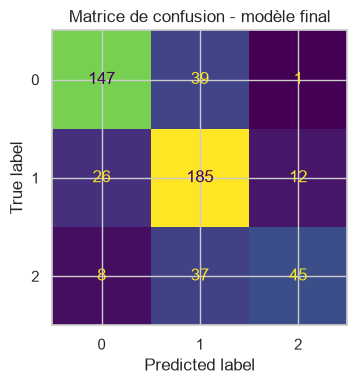


Synthèse section 5: {'variant': 'couple rang 1 de la CV (section 5.4)', 'best_scenario': 'S1_multimodal_complet', 'best_model': 'xgboost', 'test_accuracy': 0.754, 'test_f1_macro': 0.723827987167908, 'test_recall_class2': 0.5}


In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

assert "selected_scenario" in globals() and "selected_model_name" in globals(), "Exécuter la section 5.5 avant l'évaluation finale"

final_scenario = selected_scenario
final_model_name = selected_model_name
final_model = clone(candidate_models[final_model_name]).set_params(**selected_params)
final_label = "couple rang 1 de la CV (section 5.4)"

final_preprocessor = clone(scenario_data[final_scenario]["preprocessor"])
final_pipeline = Pipeline([
    ("prep", final_preprocessor),
    ("clf", final_model),
])

final_pipeline.fit(scenario_data[final_scenario]["X_train"], y_train)
y_pred = final_pipeline.predict(scenario_data[final_scenario]["X_test"])

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")
test_recall_class2 = recall_class_2(y_test, y_pred)

print("Résultats test set")
print(f"- variante: {final_label}")
print(f"- scenario: {final_scenario}")
print(f"- model: {final_model_name}")
print(f"- accuracy: {test_accuracy:.3f}")
print(f"- f1_macro: {test_f1_macro:.3f}")
print(f"- recall_classe_2: {test_recall_class2:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matrice de confusion - modèle final")
plt.tight_layout()
plt.show()

section5_summary = {
    "variant": final_label,
    "best_scenario": final_scenario,
    "best_model": final_model_name,
    "test_accuracy": float(test_accuracy),
    "test_f1_macro": float(test_f1_macro),
    "test_recall_class2": float(test_recall_class2),
}

print("\nSynthèse section 5:", section5_summary)

### 5.7 Synthèse modélisation

Le meilleur couple en validation croisée initiale est obtenu avec **XGBoost** sur le scénario **S1 multimodal complet**.

Après une recherche d'hyperparamètres restreinte à ce couple, la sélection finale de la section 5.5 atteint en **validation croisée** :
- F1 macro : **0,714**
- Recall classe 2 : **0,591**

Sur le **jeu de test** conservé pour l'évaluation finale, ce même couple obtient :
- Accuracy : **0,754**
- F1 macro : **0,724**
- Recall classe 2 : **0,500**

Lecture :
- le **F1 macro** final reste au-dessus de la cible minimale fixée (>= 0,70) ;
- le **recall de la classe 2** reste insuffisant au regard de l'objectif métier (>= 0,80) ;
- le tuning local améliore légèrement les scores globaux, sans résoudre le point le plus critique : la couverture des profils de classe 2.

Conséquence pour la suite :
- la section 6 doit arbitrer entre **performance globale**, **risque métier** et **risque de biais**, puis prioriser des ajustements orientés réduction des erreurs critiques (pondération de classes, calibration, ajustement de seuil, abstention).

---
## 6. Analyse des scénarios et arbitrages

Cette section compare les scénarios définis en section 4 selon un cadre commun : performance, risque de biais, coût et exploitabilité.
L'objectif est de documenter une recommandation finale argumentée.

### 6.1 Tableau comparatif

| Scénario | Modèle | Métrique principale | Métrique secondaire | Coût inférence | Latence p95 | Explicabilité | Dépendance fournisseur | Risque de biais et mitigation | Verdict |
|---|---|---|---|---|---|---|---|---|---|
| S1 multimodal complet | XGBoost (tuning local rank 1) | Test F1 macro = **0,724** | Test recall classe 2 = **0,500** ; erreurs critiques 2 -> 0 = **8/90** | Faible à moyen (modèle arbre boosté) | Non mesurée dans ce notebook | Moyenne (importance variables possible, pas d'explication locale native) | Faible à moyenne (librairie open source, pas d'API externe) | Exposition plus forte au risque de biais car variable sensible incluse ; mitigation : monitoring par sous-groupes + audit régulier des erreurs critiques | **Meilleure performance globale observée, mais risque métier à encadrer** |
| S2 sans variable sensible | XGBoost (meilleur modèle du scénario) | CV F1 macro = **0,679** | CV recall classe 2 = **0,542** | Faible à moyen | Non mesurée dans ce notebook | Moyenne | Faible à moyenne | Risque de discrimination directe réduit par suppression de `nationalite_hors_ue` ; mitigation complémentaire : suivi des proxys (`age`, `code_insee_commune`, `est_allocataire`) | **Option plus prudente côté conformité, avec baisse de performance** |
| S3 texte seul | LogisticRegression | CV F1 macro = **0,635** | CV recall classe 2 = **0,661** | Faible | Non mesurée dans ce notebook | Élevée (modèle linéaire plus lisible) | Faible | Risque de biais via le verbatim conseiller, potentiellement porteur de formulations sensibles ; mitigation : revue qualitative des termes influents et contrôle humain renforcé | **Scénario simple et lisible, mais pouvoir prédictif limité** |
| S4 tabulaire seul | XGBoost | CV F1 macro = **0,664** | CV recall classe 2 = **0,475** | Faible à moyen | Non mesurée dans ce notebook | Moyenne | Faible à moyenne | Moins exposé aux biais de formulation du texte, mais conserve des proxys socio-territoriaux ; mitigation : audit par sous-population et comparaison régulière avec S2 | **Compromis utile sans texte, mais insuffisant sur la classe critique** |

Le tableau combine deux niveaux de lecture : les scénarios S2 à S4 sont comparés sur leur meilleure performance en validation croisée, tandis que S1 bénéficie en plus d'une mesure finale sur jeu de test après tuning local.

### 6.2 Recommandation finale

Recommandation opérationnelle : retenir **S1 + XGBoost** comme baseline de production, avec un **garde-fou métier explicite** sur les erreurs critiques 2 -> 0.

Ce choix est motivé par la meilleure performance finale observée sur le jeu de test (accuracy 0,754 ; F1 macro 0,724), ce qui en fait l'option la plus solide pour stabiliser la qualité d'orientation au quotidien.

En contrepartie, le niveau de rappel de la classe 2 reste insuffisant (0,500) et le coût métier des faux négatifs graves demeure significatif (8 cas 2 -> 0 sur 90 en test).

Conditions de mise en oeuvre avant déploiement élargi :
- ajouter une règle d'escalade humaine pour les dossiers à faible confiance ;
- suivre en monitoring hebdomadaire la métrique 2 -> 0 et le recall classe 2 ;
- lancer un lot d'améliorations orientées risque (pondération de classes, calibration, seuil de rejet).

### 6.3 Synthèse arbitrages

Point de décision principal : **accepter le meilleur score global de S1**, tout en considérant le modèle comme **assistif** et non autonome sur les cas sensibles.

Risques résiduels acceptés à ce stade :
- recall classe 2 encore éloigné de la cible métier initiale ;
- présence possible de biais indirects via proxys socio-territoriaux ;
- latence p95 non encore mesurée dans un environnement API instrumenté.

Décision projet : passage en phase d'industrialisation contrôlée, avec plan d'amélioration continue priorisé sur la réduction des erreurs critiques.

---
## 7. Interprétation et communication métier

Cette section transforme les résultats techniques en messages opérationnels compréhensibles pour un décideur non spécialiste.
L'accent est mis sur les facteurs explicatifs, les erreurs résiduelles et les mécanismes de sécurité.

### 7.1 Variables explicatives du modèle final

Cette sous-section identifie les signaux les plus influents dans le modèle retenu. L'objectif n'est pas de fournir une causalité, mais une lecture opérationnelle des variables qui pèsent le plus dans la décision du classifieur.

,feature,importance
0,txt__correcte,0.238938
1,txt__compétences réactualiser,0.094535
2,txt__de,0.031762
3,txt__freins,0.027982
4,txt__constatée,0.023942
5,txt__compétences,0.023376
6,cat__niveau_diplome_Sans diplôme,0.023189
7,num__nationalite_hors_ue,0.019688
8,txt__affiner,0.018506
9,txt__de mobilité,0.013947


,family,importance
0,texte,0.587521
1,categorielle,0.372669
2,numerique,0.039810


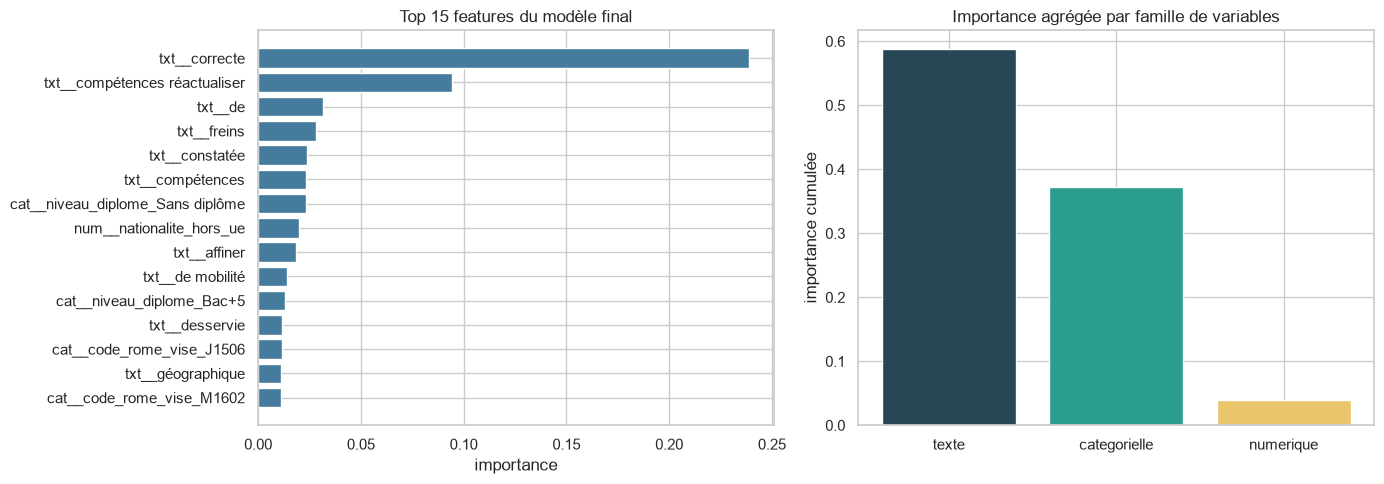

Lecture rapide section 7.1 :
- famille dominante : texte
- top feature : txt__correcte


In [92]:
import pandas as pd
import matplotlib.pyplot as plt

assert "final_pipeline" in globals(), "Exécuter la section 5.6 avant cette cellule"

clf = final_pipeline.named_steps["clf"]
prep = final_pipeline.named_steps["prep"]

if not hasattr(clf, "feature_importances_"):
    raise TypeError("Le modèle final ne fournit pas de feature_importances_.")

num_names = [f"num__{name}" for name in final_preprocessor.transformers_[0][2]]
cat_encoder = final_preprocessor.named_transformers_["cat"].named_steps["encoder"]
cat_input_names = final_preprocessor.transformers_[1][2]
cat_names = [f"cat__{name}" for name in cat_encoder.get_feature_names_out(cat_input_names)]
text_vectorizer = final_preprocessor.named_transformers_["txt"].named_steps["tfidf"]
text_names = [f"txt__{name}" for name in text_vectorizer.get_feature_names_out()]

feature_names = num_names + cat_names + text_names
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": clf.feature_importances_,
})

importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
top_features = importance_df.head(15).copy()

def feature_family(name: str) -> str:
    if name.startswith("txt__"):
        return "texte"
    if name.startswith("num__"):
        return "numerique"
    if name.startswith("cat__"):
        return "categorielle"
    return "autre"

importance_df["family"] = importance_df["feature"].apply(feature_family)
family_importance = (
    importance_df.groupby("family", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(top_features)
display(family_importance)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_features["feature"].iloc[::-1], top_features["importance"].iloc[::-1], color="#457b9d")
axes[0].set_title("Top 15 features du modèle final")
axes[0].set_xlabel("importance")

axes[1].bar(family_importance["family"], family_importance["importance"], color=["#264653", "#2a9d8f", "#e9c46a", "#e76f51"][:len(family_importance)])
axes[1].set_title("Importance agrégée par famille de variables")
axes[1].set_ylabel("importance cumulée")

plt.tight_layout()
plt.show()

print("Lecture rapide section 7.1 :")
print(f"- famille dominante : {family_importance.iloc[0]['family']}")
print(f"- top feature : {top_features.iloc[0]['feature']}")

### 7.2 Analyse des erreurs et stratégies de fallback

Cette section formalise le comportement du système dans les cas incertains ou risqués.

Constat principal issu de l'analyse exécutée : un seuil simple de confiance à **0,55** conduit à escalader **18,6 %** des dossiers, mais ne capte que **2 erreurs critiques sur 8** (`2 -> 0`).
Cela signifie qu'une règle de rejet fondée uniquement sur la probabilité maximale est utile, mais insuffisante si l'objectif est de sécuriser tous les cas métier les plus sensibles.

| Levier | Question de conception | Proposition retenue à ce stade |
|---|---|---|
| Rejection threshold | À partir de quel niveau de confiance s'abstenir ? | Tester un seuil initial à **0,55** pour déclencher une revue humaine sur les dossiers les moins stables. |
| Abstention contrôlée | Quelle réponse API renvoyer en cas d'abstention ? | Retourner une réponse du type `statut = a_revoir`, avec classe proposée, score de confiance et motif d'escalade. |
| Escalade humaine (HITL) | Qui reprend la décision, dans quel délai ? | Relecture par un conseiller ou référent métier sur les dossiers à faible confiance et sur certains profils à risque explicites. |

Lecture opérationnelle :
- la confiance prédictive distingue partiellement les bonnes prédictions des erreurs, mais pas assez pour couvrir seule le risque critique ;
- une stratégie plus robuste combinera **faible confiance**, **classe prédite sensible** et éventuellement **règles métier ciblées** ;
- cette logique renforce le positionnement du modèle comme **outil d'aide à la décision**, non comme automate de décision finale.

Le code associé fournit une première base pour calibrer cette politique d'escalade.

,n_test,error_rate,critical_2_to_0,pct_low_confidence,critical_captured_by_rule
0,500,0.246,8,0.186,2


,y_true,y_pred,confidence,is_error,is_critical_2_to_0,age,niveau_diplome,est_allocataire,nationalite_hors_ue
1793,1,0,0.444843,True,False,58.0,Bac+5,1.0,1
1186,1,0,0.460192,True,False,47.0,Bac+2,1.0,0
1892,2,1,0.471214,True,False,24.0,Bac,0.0,1
2267,1,1,0.462457,False,False,62.0,Bac,0.0,0
1295,1,0,0.495355,True,False,60.0,Bac,NaN,0
1850,2,0,0.662440,True,True,28.0,Bac,0.0,0
1539,0,2,0.440733,True,False,26.0,Bac+5,1.0,1
1267,0,1,0.409841,True,False,22.0,Bac,1.0,0
327,2,2,0.460353,False,False,61.0,Bac+5,0.0,0
940,1,1,0.412509,False,False,NaN,Bac,0.0,0


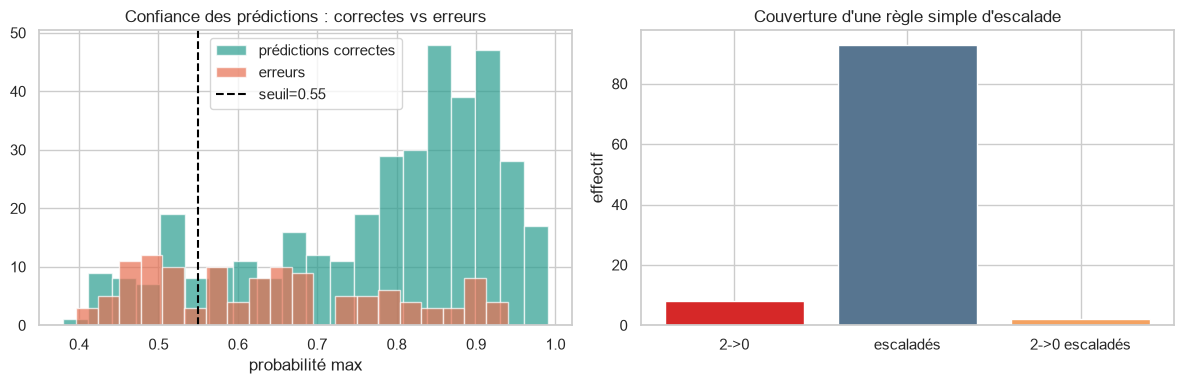

Lecture rapide section 7.2 :
- seuil d'escalade testé : 0.55
- part de dossiers escaladés : 0.186
- erreurs critiques 2->0 : 8
- erreurs critiques captées par la règle : 2


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "final_pipeline" in globals(), "Exécuter la section 5.6 avant cette cellule"

proba = final_pipeline.predict_proba(scenario_data[final_scenario]["X_test"])
confidence = proba.max(axis=1)
pred_class = proba.argmax(axis=1)

error_analysis = scenario_data[final_scenario]["X_test"].copy()
error_analysis["y_true"] = y_test.to_numpy()
error_analysis["y_pred"] = y_pred
error_analysis["confidence"] = confidence
error_analysis["is_error"] = error_analysis["y_true"] != error_analysis["y_pred"]
error_analysis["is_critical_2_to_0"] = (error_analysis["y_true"] == 2) & (error_analysis["y_pred"] == 0)

threshold = 0.55
error_analysis["escalate_low_confidence"] = error_analysis["confidence"] < threshold

summary_72 = {
    "n_test": int(len(error_analysis)),
    "error_rate": float(error_analysis["is_error"].mean()),
    "critical_2_to_0": int(error_analysis["is_critical_2_to_0"].sum()),
    "pct_low_confidence": float(error_analysis["escalate_low_confidence"].mean()),
    "critical_captured_by_rule": int(error_analysis.loc[error_analysis["is_critical_2_to_0"], "escalate_low_confidence"].sum()),
}

escalation_profiles = error_analysis.loc[
    error_analysis["escalate_low_confidence"] | error_analysis["is_critical_2_to_0"],
    ["y_true", "y_pred", "confidence", "is_error", "is_critical_2_to_0", "age", "niveau_diplome", "est_allocataire", "nationalite_hors_ue"]
].head(15)

display(pd.DataFrame([summary_72]))
display(escalation_profiles)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(error_analysis.loc[~error_analysis["is_error"], "confidence"], bins=20, alpha=0.7, label="prédictions correctes", color="#2a9d8f")
axes[0].hist(error_analysis.loc[error_analysis["is_error"], "confidence"], bins=20, alpha=0.7, label="erreurs", color="#e76f51")
axes[0].axvline(threshold, color="black", linestyle="--", label=f"seuil={threshold}")
axes[0].set_title("Confiance des prédictions : correctes vs erreurs")
axes[0].set_xlabel("probabilité max")
axes[0].legend()

critical_counts = pd.Series({
    "2->0": int(error_analysis["is_critical_2_to_0"].sum()),
    "escaladés": int(error_analysis["escalate_low_confidence"].sum()),
    "2->0 escaladés": int(error_analysis.loc[error_analysis["is_critical_2_to_0"], "escalate_low_confidence"].sum()),
})
axes[1].bar(critical_counts.index, critical_counts.values, color=["#d62828", "#577590", "#f4a261"])
axes[1].set_title("Couverture d'une règle simple d'escalade")
axes[1].set_ylabel("effectif")

plt.tight_layout()
plt.show()

print("Lecture rapide section 7.2 :")
print(f"- seuil d'escalade testé : {threshold}")
print(f"- part de dossiers escaladés : {summary_72['pct_low_confidence']:.3f}")
print(f"- erreurs critiques 2->0 : {summary_72['critical_2_to_0']}")
print(f"- erreurs critiques captées par la règle : {summary_72['critical_captured_by_rule']}")

### 7.3 Message au client (langage métier)

Le modèle proposé aide à repérer des profils de retour à l'emploi plus ou moins rapides à partir d'un mélange d'informations administratives, socio-professionnelles et textuelles issues de l'entretien. Dans sa configuration actuelle, il apporte une aide utile pour homogénéiser l'orientation initiale et traiter rapidement un volume important de dossiers, avec une performance globale correcte sur le jeu de test.

En revanche, il ne doit pas être interprété comme un outil de décision autonome. Le point de vigilance principal reste la détection des situations les plus fragiles : le modèle identifie encore imparfaitement une partie des usagers à risque de retour à l'emploi long, et certaines erreurs critiques subsistent. Pour cette raison, son usage recommandé est celui d'un **assistant de tri et d'orientation**, complété par une revue humaine sur les cas incertains ou sensibles.

L'analyse des variables influentes montre aussi que le texte d'entretien pèse fortement dans la prédiction. C'est utile, car le verbatim contient de l'information métier riche, mais cela impose une vigilance particulière sur la qualité de rédaction, les biais de formulation et la traçabilité des recommandations produites.

### 7.4 Synthèse interprétation

Points clés à retenir :
- le **texte** est la famille de variables la plus influente dans le modèle final (importance cumulée d'environ **0,588**), devant les variables catégorielles (**0,373**) puis numériques (**0,040**) ;
- parmi les signaux les plus importants figurent plusieurs termes du verbatim, le niveau de diplôme et la variable `nationalite_hors_ue`, ce qui justifie une vigilance éthique renforcée ;
- une règle simple d'escalade à faible confiance (`< 0,55`) capte une partie des erreurs, mais pas suffisamment les erreurs critiques `2 -> 0` ;
- la bonne stratégie opérationnelle n'est donc pas seulement de prédire, mais de **prédire puis filtrer intelligemment les cas à revoir**.

Recommandations opérationnelles :
- conserver le modèle comme aide à la décision et non comme décisionnaire autonome ;
- compléter la logique d'escalade par des règles métier plus ciblées que le seul seuil de confiance ;
- poursuivre ensuite avec des outils d'explicabilité locale et de calibration pour mieux sécuriser les cas sensibles.

---
## 8. Industrialisation

Cette section décrit l'architecture de mise en production : persistance du modèle, API, conteneurisation et chaîne d'intégration continue.
Le code applicatif vit dans le repository ; le notebook conserve la vue d'ensemble et les choix techniques.

Composants visés :
- API FastAPI (`/predict`, `/health`, `/train` optionnel) ;
- validation des entrées ;
- journalisation structurée ;
- tests automatisés ;
- conteneurisation Docker ;
- CI/CD ;
- suivi d'expériences (MLflow).

### 8.1 Persistance du modèle

*[Modèle servi, format d'artefact (ex. pipeline.joblib), versionnement et traçabilité.]*

### 8.2 API de service

Repository associé : `<lien GitHub>` — dossier `api/`

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | vérifier l'état du service | — |
| `/predict` | POST | prédiction unitaire | schéma d'entrée validé |
| `/train` | POST | déclenchement de réentraînement (optionnel) | validation + contrôle d'accès |

### 8.3 Interface utilisateur

*[Interface de démonstration éventuelle (Streamlit, Gradio, autre) + capture.]*

### 8.4 Schéma d'architecture

```mermaid
graph LR
  D[(Données)] --> P[Préprocessing] --> M[Modèle .joblib]
  M --> A[FastAPI]
  A --> U[UI Streamlit]
  A --> L[(Logs)]
  L --> Mo[Monitoring]
```

### 8.5 Conteneurisation et CI/CD

*[Références Dockerfile, docker-compose, workflow CI, captures de pipeline.]*

### 8.6 Synthèse industrialisation

*[Architecture retenue, décisions clés, points encore ouverts.]*

---
## 9. Suivi en production et amélioration continue

Cette section définit le pilotage du modèle après mise en service : surveillance, détection de dérive, boucle de retour et règles de réentraînement.
L'objectif est d'assurer la stabilité opérationnelle dans le temps.

### 9.1 Métriques à surveiller

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Modèle | F1 hebdo | < baseline - 0.05 | logs API |
| Données | PSI variables clés | > 0.2 | batch journalier |
| Système | latence p95 | > 500 ms | Prometheus |

### 9.2 Boucle de rétroaction

*[Comment les retours utilisateurs sont intégrés dans les données d'entraînement.]*

### 9.3 Plan de réentraînement

*[Déclencheurs, validation avant promotion, cadence cible.]*

### 9.4 Robustesse en exploitation

| Axe | Métrique opérationnelle | Action |
|---|---|---|
| OOD (Out-Of-Distribution) | score de distance / isolation | journalisation + abstention ou escalade |
| Drift du seuil de rejet | taux d'abstention | recalibrage du seuil si dérive persistante |
| Calibration | Brier score, courbe de calibration | recalibrage sans réentraînement complet si possible |

### 9.5 Synthèse amélioration continue

*[Cadence de suivi, déclencheurs de remédiation, plan d'action.]*

---
## Annexes

### A. Glossaire métier et technique

### B. Sources et bibliographie

- *[datasets, articles, documentations techniques utilisés]*

### C. Décisions techniques détaillées

*[Justifications longues conservées hors du flux principal pour garder le notebook lisible.]*

### D. Journal de bord

Le journal de bord est maintenu dans `reports/journal/journal-de-bord.ipynb` et alimente la traçabilité du projet.
En cas de version de soutenance unifiée, les contenus peuvent être fusionnés dans un document unique.

### E. Vérification finale

- Le notebook s'exécute de bout en bout sans erreur.
- Les visualisations sont accessibles et reproductibles.
- Les références externes sont explicites et disponibles.
- La version finale est datée et archivée.